# Kumaraswamy Distribution

`Kumaraswamy(shape1, shape2)` is a continuous distribution on [0, 1] for proportions and probabilities. Both shape parameters must be positive: larger `shape1` shifts values toward 1, larger `shape2` shifts them toward 0.

In [1]:
from symbulate import *

## Draw a value from a Kumaraswamy distribution

In [2]:
Kumaraswamy(shape1=2, shape2=5).draw()

0.5866556247583093

## Theoretical mean, variance, and standard deviation

In [3]:
Kumaraswamy(shape1=2, shape2=5).mean(), Kumaraswamy(shape1=2, shape2=5).var(), Kumaraswamy(shape1=2, shape2=5).sd()

(np.float64(0.3694083694083694),
 np.float64(0.03020412327771635),
 np.float64(0.17379333496344546))

## Assign and simulate a random variable

In [4]:
K1 = RV(Kumaraswamy(shape1=2, shape2=5))
K1.sim(10000)

0,0.18569327763217228
1,0.44023872114168816
2,0.06442366360471993
3,0.23266509076285985
4,0.5036792098189371
5,0.3034814550295688
6,0.5365841744948042
7,0.5547199276795372
8,0.36805539145002103
...,...
9999,0.604063622987281


## Plot the pdf

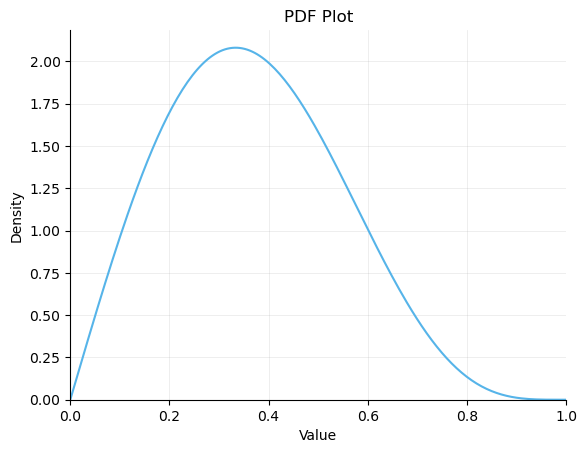

In [5]:
Kumaraswamy(shape1=2, shape2=5).plot()

## Plot the CDF

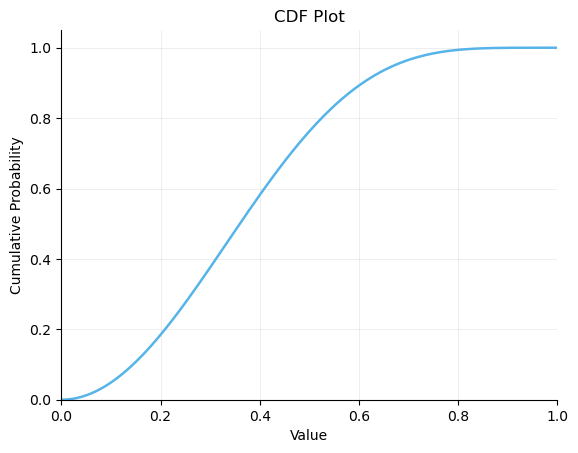

In [6]:
Kumaraswamy(shape1=2, shape2=5).plot(cdf=True)

## Special case: shape1 = 1 is the Beta(1, shape2) distribution

With `shape1 = 1` the cdf is `1 - (1 - x) ** shape2`, which is exactly the cdf of `Beta(1, shape2)`. The two curves land on top of each other.

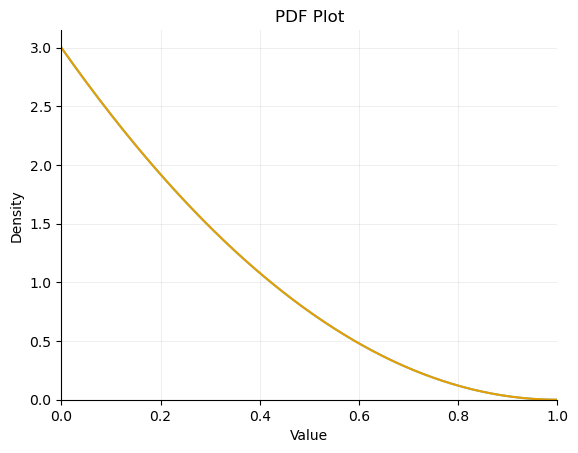

In [7]:
Kumaraswamy(shape1=1, shape2=3).plot()
Beta(shape1=1, shape2=3).plot()

## Special case: shape2 = 1 is the Beta(shape1, 1) distribution

With `shape2 = 1` the cdf is `x ** shape1`, which is exactly the cdf of `Beta(shape1, 1)`.

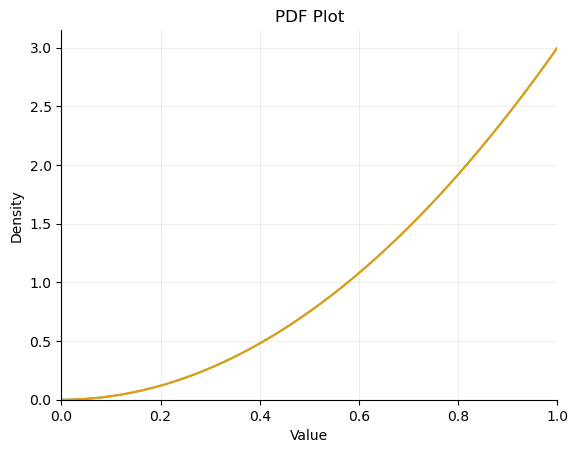

In [8]:
Kumaraswamy(shape1=3, shape2=1).plot()
Beta(shape1=3, shape2=1).plot()

## Shape parameters change the curve

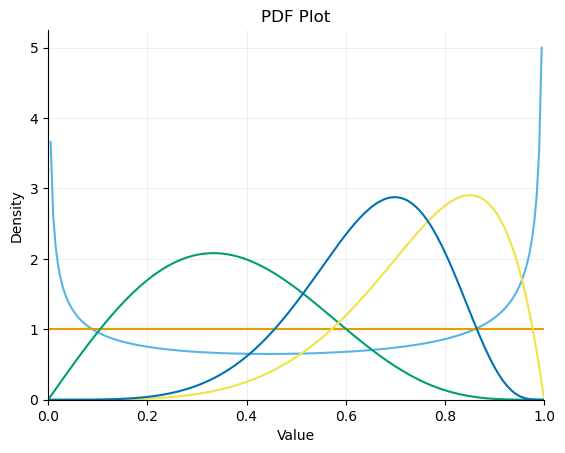

In [9]:
for shape1, shape2 in [(0.5, 0.5), (1, 1), (2, 5), (5, 2), (5, 5)]:
    Kumaraswamy(shape1=shape1, shape2=shape2).plot()

## Relationships

Each construction below is simulated, drawn as a normalized histogram, and overlaid with the theoretical `Kumaraswamy` density; the last section compares the Kumaraswamy against the `Beta` directly. All of them require `shape1 > 0` and `shape2 > 0`.

### Building a Kumaraswamy from a Uniform

If `U` is `Uniform(0, 1)`, then

$$X = \left(1 - (1 - U)^{1/shape2}\right)^{1/shape1}$$

has a `Kumaraswamy(shape1, shape2)` distribution. This is the inverse-cdf construction: the formula is the Kumaraswamy quantile function, so it works for **any** `shape1 > 0` and `shape2 > 0`. Below, `shape1 = 2` and `shape2 = 5`.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


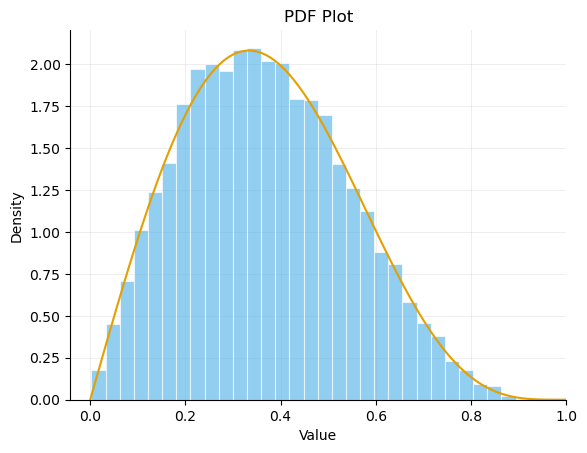

In [10]:
shape1, shape2 = 2, 5

U = RV(Uniform(0, 1))
X = (1 - (1 - U) ** (1 / shape2)) ** (1 / shape1)

X.sim(10000).plot(type="hist")
Kumaraswamy(shape1=shape1, shape2=shape2).plot()

### Special case shape1 = 1: a transformed Uniform, and a Beta(1, shape2)

Setting `shape1 = 1` collapses the construction to $X = 1 - (1 - U)^{1/shape2}$, and `Kumaraswamy(1, shape2)` **is** `Beta(1, shape2)` exactly. Simulating from `Beta(1, shape2)` and overlaying the Kumaraswamy density shows the same distribution twice. Here `shape2 = 3`; the equality holds only because `shape1 = 1`.

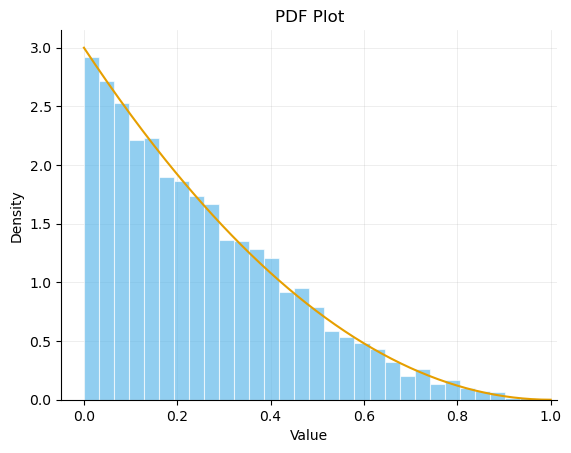

In [11]:
shape2 = 3

RV(Beta(shape1=1, shape2=shape2)).sim(10000).plot(type="hist")
Kumaraswamy(shape1=1, shape2=shape2).plot()

### Special case shape2 = 1: a power of a Uniform, and a Beta(shape1, 1)

Setting `b = 1` collapses the construction to $X = U^{1/a}$, and `Kumaraswamy(a, 1)` **is** `Beta(a, 1)` exactly — the power-function distribution. Here `a = 4`; the equality holds only because `b = 1`.

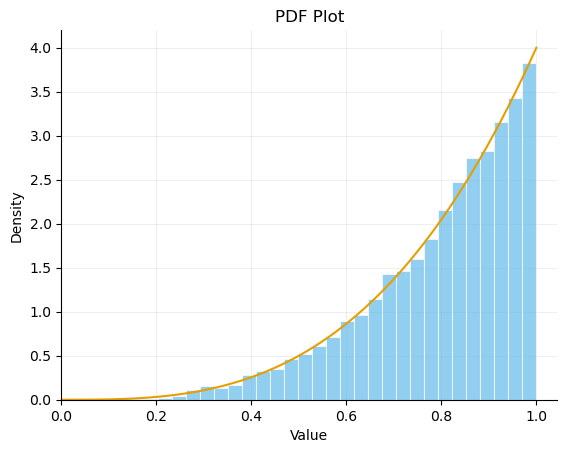

In [12]:
shape1 = 4

U = RV(Uniform(0, 1))
(U ** (1 / shape1)).sim(10000).plot(type="hist")
Kumaraswamy(shape1=shape1, shape2=1).plot()

### The general link to the Beta: a root of a Beta(1, shape2)

For general `a` and `b` the Kumaraswamy is not a Beta, but the two families are still connected: if `Y` is `Beta(1, b)`, then $Y^{1/a}$ is `Kumaraswamy(shape1, shape2)`. (Equivalently, if `X` is `Kumaraswamy(shape1, shape2)`, then $X^a$ is `Beta(1, b)`.) Note the first Beta parameter must be **1** — no other Beta works. Below, `a = 3` and `b = 2`.

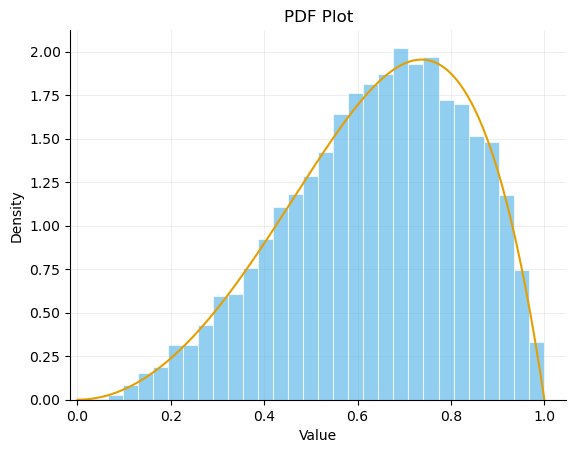

In [13]:
shape1, shape2 = 3, 2

Y = RV(Beta(shape1=1, shape2=shape2))
(Y ** (1 / shape1)).sim(10000).plot(type="hist")
Kumaraswamy(shape1=shape1, shape2=shape2).plot()

### Kumaraswamy compared to Beta

Outside the two special cases, `Kumaraswamy(shape1, shape2)` and `Beta(a, b)` with the *same* parameter values are different distributions — same support and a similar shape, but not the same curve.

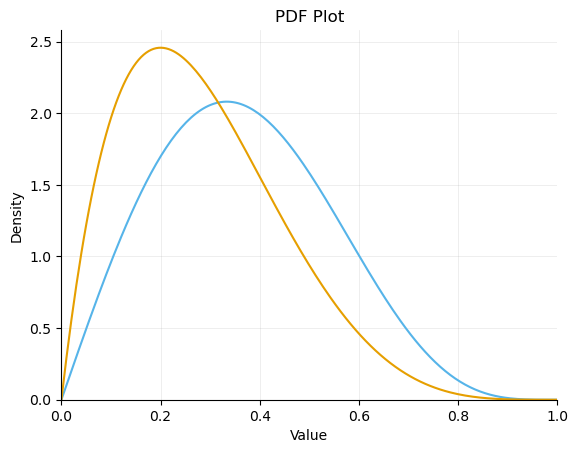

In [14]:
Kumaraswamy(shape1=2, shape2=5).plot()
Beta(shape1=2, shape2=5).plot()

In [15]:
Kumaraswamy(shape1=2, shape2=5).mean(), Beta(shape1=2, shape2=5).mean()

(np.float64(0.3694083694083694), np.float64(0.2857142857142857))

Matching the Beta's parameters to the Kumaraswamy's mean and variance brings the two much closer, but they still differ in the tails — the families overlap only at `a = 1` and `b = 1`.

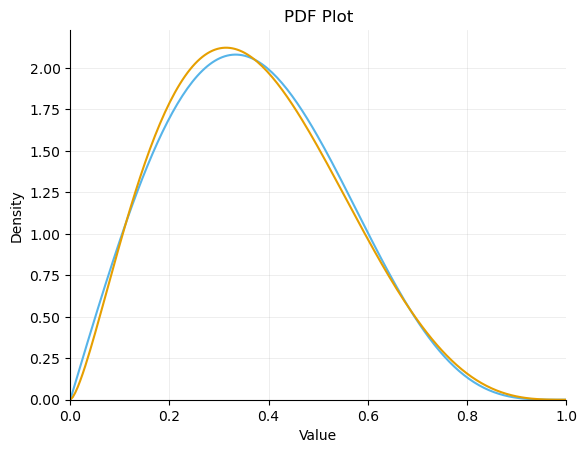

In [16]:
K = Kumaraswamy(shape1=2, shape2=5)
m, v = float(K.mean()), float(K.var())
c = m * (1 - m) / v - 1  # matches a Beta's mean and variance to K's

K.plot()
Beta(shape1=m * c, shape2=(1 - m) * c).plot()